# Comparación de modelos

El siguiente documento presenta los entrenamientos de varios modelos usando datos agregados del experimento 1st_test. este sirve como punto de partida y comparación para arquitecturas más complejas.

Los modelos empleados son: 
- Convolutional Neural Network (CNN)
- Long Short-Term Memory (LSTM)
- Recurrent Neural Network (RNN)
- Deep Neural Network (DNN)


 

El conjunto de datos usado se componen de 17.248 filas y 21 columnas. En este cada fila corresponde a una medición del experimento 1st_test, es el primero de 3 experimentos que conforman el dataset [IMS-Rexnord Bearing](https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/) realizado en la universidad de Cincinnati cuyos investigadores dispusieron datos sobre viabraciones elementos rodantes. Las columnas corresponde a diferentes parámetros y estadísticos, algunos de ellos son: amplitud máxima, amplitud promedio, error cuadrático medio, varianza, desviación estándar, entre otros.

En este documento se emplea el conjunto de datos descrito, pero modificado como se describe en el archivo `TF_Generador_Datasets.ipynb` para generar un solo conjunto de datos tabulados. Para entrenar los modelos en el conjunto de datos compuesto de 21 columnas y 17.248 filas se agrupó cada 8 filas, correspondiente a cada sensor del experimento 1st_test,  para crear un tensor de la forma (2156 filas , 8 sensores, 21 columnas). Este proceso de agrupación permite que los modelos entiendan la relacion entre los canales de los experimentos, sin embargo esto provoca que se pierdan algunas etiquetas asignadas a cada canal, siendo orginalmente 7, sólo se utilizan 4.

# Modificaciones
En esta v4, se realizaron las siguientes modificaciones:
- Empleo del conjunto de validación para el entrenamiento
- Balanceo de clases en el conjunto de train
- Empleo de Wanbd para registrar métricas y resultados

# Tabla de resultados 

VALIDATION

| MODELO       | PRECISIÓN    | RECALL       |  F1 - SCORE  | 
|--------------|--------------|--------------|--------------|
| XGBoost      | 0.87         |  0.87        |     0.87     |
| CNN          | 0.85         |  0.85        |     0.84     |
| RNN          | 0.86         |  0.88        |     0.87     |
| LSTM         | 0.83         |  0.88        |     0.85     |
| DNN          | 0.80         |  0.86        |     0.82     |


TEST 

| MODELO       | PRECISIÓN    | RECALL       |  F1 - SCORE  | 
|--------------|--------------|--------------|--------------|
| XGBoost      | 0.92         |  0.93        |     0.92     |
| CNN          | 0.81         |  0.78        |     0.78     |
| RNN          | 0.83         |  0.84        |     0.83     |
| LSTM         | 0.79         |  0.85        |     0.81     |
| DNN          | 0.83         |  0.83        |     0.83     |




## Resultados de Entrenamiento

### XGBoost
<div style="display: flex; gap: 10px;">
  <img src="artefactos/artefactos_train_v5/matriz_confusion_xgboost_validacion.png" width="48%">
  <img src="artefactos/artefactos_train_v5/matriz_confusion_xgboost_test.png" width="48%">
</div>

### CNN
<div style="display: flex; gap: 10px;">
  <img src="artefactos/artefactos_train_v5/accuracy_epoch_cnn.png" width="32%">
  <img src="artefactos/artefactos_train_v5/matriz_confusion_cnn_validation.png" width="32%">
  <img src="artefactos/artefactos_train_v5/matriz_confusion_cnn_test.png" width="32%">
</div>

### RNN
<div style="display: flex; gap: 10px;">
  <img src="artefactos/artefactos_train_v5/accuracy_epoch_rnn.png" width="32%">
  <img src="artefactos/artefactos_train_v5/matriz_confusion_rnn_validation.png" width="32%">
  <img src="artefactos/artefactos_train_v5/matriz_confusion_rnn_test.png" width="32%">
</div>

### LSTM
<div style="display: flex; gap: 10px;">
  <img src="artefactos/artefactos_train_v5/accuracy_epoch_lstm.png" width="32%">
  <img src="artefactos/artefactos_train_v5/matriz_confusion_lstm_validation.png" width="32%">
  <img src="artefactos/artefactos_train_v5/matriz_confusion_lstm_test.png" width="32%">
</div>

### DNN
<div style="display: flex; gap: 10px;">
  <img src="artefactos/artefactos_train_v5/accuracy_epoch_dnn.png" width="32%">
  <img src="artefactos/artefactos_train_v5/matriz_confusion_dnn_validation.png" width="32%">
  <img src="artefactos/artefactos_train_v5/matriz_confusion_dnn_test.png" width="32%">
</div>

# Declaración de librerías


In [1]:
# LIBRERIAS
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten
from tensorflow.keras.models import Sequential

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import precision_recall_fscore_support
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint
import wandb


2026-04-20 17:52:47.234606: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-20 17:52:47.234710: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-20 17:52:47.268564: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-20 17:52:47.334296: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-20 17:52:48.326505: W tensorflow/compiler/tf2

In [2]:
import keras_tuner as kt
# métrica F1 macro compatible con multiclase
class F1MacroScore(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.true_positives  = self.add_weight(name='tp', shape=(num_classes,), initializer='zeros')
        self.false_positives = self.add_weight(name='fp', shape=(num_classes,), initializer='zeros')
        self.false_negatives = self.add_weight(name='fn', shape=(num_classes,), initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_classes = tf.argmax(y_pred, axis=1)
        y_true_flat    = tf.cast(tf.reshape(y_true, [-1]), tf.int64)

        # one-hot encoding vectorizado — sin loops
        y_true_oh = tf.one_hot(y_true_flat,    self.num_classes)  # (batch, num_classes)
        y_pred_oh = tf.one_hot(y_pred_classes, self.num_classes)  # (batch, num_classes)

        self.true_positives.assign_add(
            tf.reduce_sum(y_true_oh * y_pred_oh, axis=0)
        )
        self.false_positives.assign_add(
            tf.reduce_sum((1 - y_true_oh) * y_pred_oh, axis=0)
        )
        self.false_negatives.assign_add(
            tf.reduce_sum(y_true_oh * (1 - y_pred_oh), axis=0)
        )

    def result(self):
        precision    = self.true_positives / (self.true_positives + self.false_positives + 1e-7)
        recall       = self.true_positives / (self.true_positives + self.false_negatives + 1e-7)
        f1_per_class = 2 * precision * recall / (precision + recall + 1e-7)
        return tf.reduce_mean(f1_per_class)

    def reset_state(self):
        for var in self.variables:
            var.assign(tf.zeros_like(var))

In [3]:
# Carpeta de artefactos, modelos y resultados
dir_artifacts = "artefactos/artefactos_train_v5"

# crear carpeta si no existe
import os
os.makedirs(dir_artifacts, exist_ok=True)

# Limpieza y armado de tensores

In [4]:
df = pd.read_csv("../datos/datos_generados/estadisticos_agregados/dataset_agregado_1st_test_con_salud.csv")

In [5]:
df.head()

,archivo,canal,peak_amplitude,mean_amplitude,rms_amplitude,peak_to_peak_amplitude,crest_factor,variance,standard_deviation,standard_error,...,skewness,kurtosis,hoc3,hoc4,entropy,mean_frequency,rms_frequency,envelope_rms,salud,salud_miltos
0,2003.10.22.12.06.24,Canal 1,0.5540,-0.094596,0.124617,1.108,4.445630,0.006581,0.081122,0.000567,...,-0.029898,1.069246,-0.000016,0.000046,1.178086,3011.599741,3669.348883,0.148695,saludable,Early
1,2003.10.22.12.06.24,Canal 2,0.6325,-0.093883,0.117496,1.265,5.383175,0.004991,0.070649,0.000494,...,0.220211,3.065961,0.000078,0.000076,0.936417,3965.247247,4995.648585,0.137100,NaN,Early
2,2003.10.22.12.06.24,Canal 3,0.5165,-0.093812,0.130452,1.033,3.959305,0.008217,0.090648,0.000633,...,-0.092175,0.209605,-0.000069,0.000014,1.338470,3002.578036,3950.131469,0.158855,NaN,Early
3,2003.10.22.12.06.24,Canal 4,0.3930,-0.093753,0.121644,0.786,3.230726,0.006008,0.077509,0.000542,...,-0.053114,0.292136,-0.000025,0.000011,1.435646,3355.919142,4567.916463,0.144240,NaN,Early
4,2003.10.22.12.06.24,Canal 5,0.4480,-0.090811,0.128888,0.896,3.475883,0.008365,0.091463,0.000639,...,0.034348,0.405279,0.000026,0.000028,1.476715,4377.833157,5106.402925,0.158043,NaN,Early


## Analisis de correlación


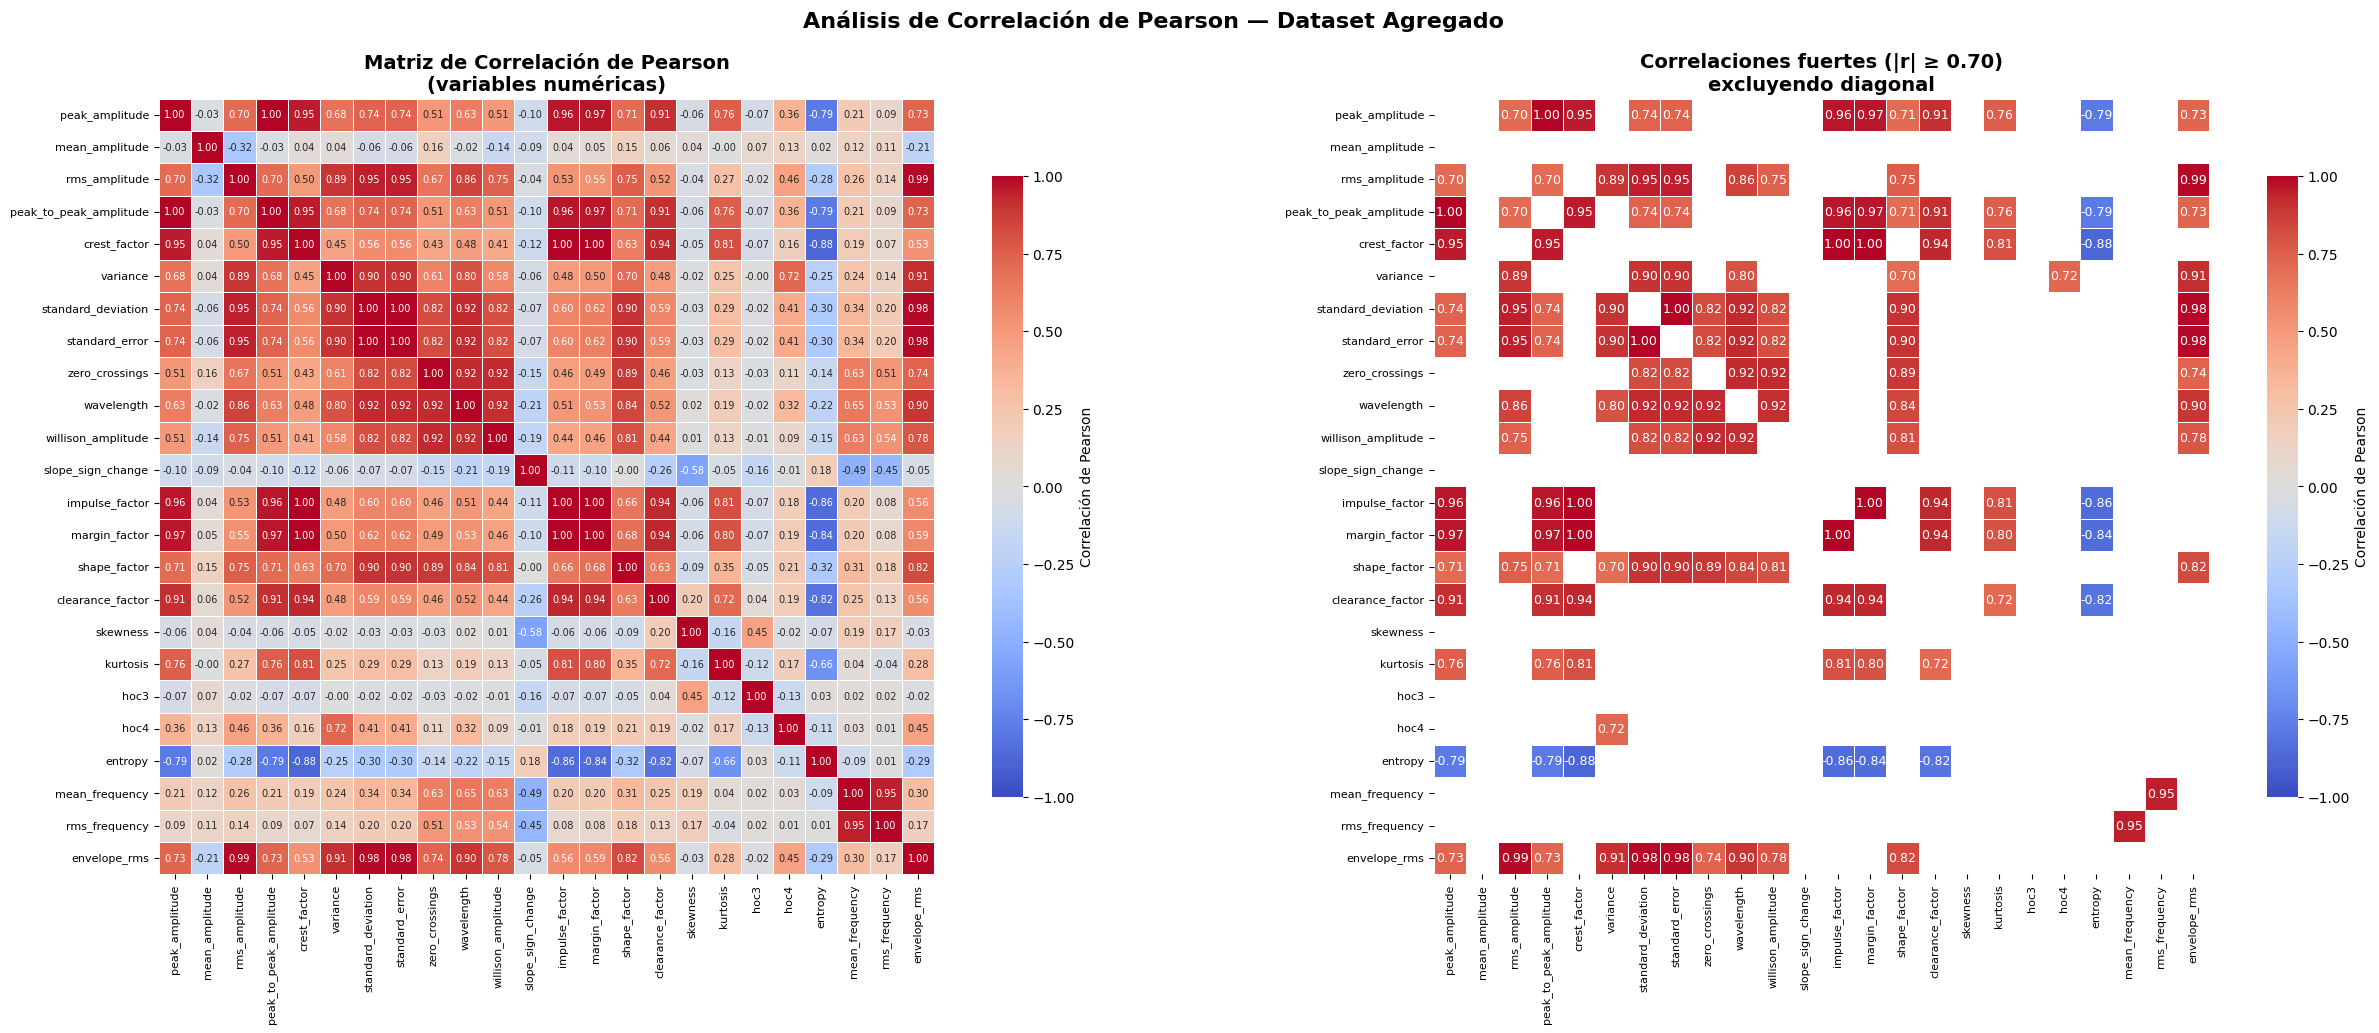


Variables numéricas analizadas (24):
['peak_amplitude', 'mean_amplitude', 'rms_amplitude', 'peak_to_peak_amplitude', 'crest_factor', 'variance', 'standard_deviation', 'standard_error', 'zero_crossings', 'wavelength', 'willison_amplitude', 'slope_sign_change', 'impulse_factor', 'margin_factor', 'shape_factor', 'clearance_factor', 'skewness', 'kurtosis', 'hoc3', 'hoc4', 'entropy', 'mean_frequency', 'rms_frequency', 'envelope_rms']

Pares con correlación fuerte (|r| ≥ 0.70): 72
            Variable 1             Variable 2  Pearson r
    standard_deviation         standard_error   1.000000
        peak_amplitude peak_to_peak_amplitude   1.000000
        impulse_factor          margin_factor   0.999403
          crest_factor         impulse_factor   0.998352
          crest_factor          margin_factor   0.996001
         rms_amplitude           envelope_rms   0.990552
        standard_error           envelope_rms   0.984625
    standard_deviation           envelope_rms   0.984625
peak_t

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
# df = pd.read_csv("../datos/datos_generados/estadisticos_agregados/dataset_agregado_1st_test_con_salud.csv")

# Seleccionar solo columnas numéricas
df_num = df.select_dtypes(include=[np.number])

# Calcular matriz de correlación de Pearson
corr_matrix = df_num.corr(method='pearson')

# ── Figura ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(26, 10))

# 1) Heatmap completo
sns.heatmap(
    corr_matrix,
    ax=axes[0],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={"size": 7},
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Correlación de Pearson"}
)
axes[0].set_title("Matriz de Correlación de Pearson\n(variables numéricas)", fontsize=14, fontweight="bold")
axes[0].tick_params(axis='x', rotation=90, labelsize=8)
axes[0].tick_params(axis='y', rotation=0,  labelsize=8)

# 2) Heatmap de correlaciones fuertes (|r| >= 0.7), excluyendo la diagonal
mask_weak = (corr_matrix.abs() < 0.7)
np.fill_diagonal(mask_weak.values, True)   # ocultar diagonal

sns.heatmap(
    corr_matrix,
    ax=axes[1],
    mask=mask_weak,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={"size": 9},
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Correlación de Pearson"}
)
axes[1].set_title("Correlaciones fuertes (|r| ≥ 0.70)\nexcluyendo diagonal", fontsize=14, fontweight="bold")
axes[1].tick_params(axis='x', rotation=90, labelsize=8)
axes[1].tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle("Análisis de Correlación de Pearson — Dataset Agregado", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("correlacion_pearson.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Resumen en consola ───────────────────────────────────────────────────────
print(f"\nVariables numéricas analizadas ({len(df_num.columns)}):")
print(list(df_num.columns))

# Pares con correlación fuerte (|r| >= 0.7), sin duplicados ni diagonal
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
strong = (
    upper.stack()
         .reset_index()
         .rename(columns={"level_0": "Variable 1", "level_1": "Variable 2", 0: "Pearson r"})
         .assign(**{"|r|": lambda x: x["Pearson r"].abs()})
         .query("`|r|` >= 0.7")
         .sort_values("|r|", ascending=False)
         .reset_index(drop=True)
)

print(f"\nPares con correlación fuerte (|r| ≥ 0.70): {len(strong)}")
print(strong[["Variable 1", "Variable 2", "Pearson r"]].to_string(index=False))

In [ ]:
# ELIMINAR COLUMNAS CON UNA ALTA CORRELACIÓN (|r| > UMBRAL)
import pandas as pd
import numpy as np

# Cargar datos
# df = pd.read_csv("../datos/datos_generados/estadisticos_agregados/dataset_agregado_1st_test_con_salud.csv")

# ── Parámetros ───────────────────────────────────────────────────────────────
UMBRAL = 0.4  # cambia este valor según necesites

# ── Separar columnas numéricas y no numéricas ────────────────────────────────
df_num = df.select_dtypes(include=[np.number])
df_cat = df.select_dtypes(exclude=[np.number])

# ── Matriz de correlación (triángulo superior sin diagonal) ──────────────────
corr_matrix = df_num.corr(method='pearson').abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# ── Identificar columnas a eliminar ─────────────────────────────────────────
# Por cada par correlacionado, se elimina la segunda columna (la de la derecha)
cols_eliminar = set()
for col in upper.columns:
    if any(upper[col] > UMBRAL):
        cols_eliminar.add(col)

cols_mantener = [c for c in df_num.columns if c not in cols_eliminar]

# seleccion manual (opcional)
# cols_mantener = ['peak_amplitude', 'mean_amplitude', 'slope_sign_change']

# ── Reporte ──────────────────────────────────────────────────────────────────
print(f"Umbral aplicado : |r| > {UMBRAL}")
print(f"Variables originales : {len(df_num.columns)}")
print(f"Variables eliminadas : {len(cols_eliminar)}")
print(f"Variables conservadas: {len(cols_mantener)}")

# print(f"\nColumnas ELIMINADAS ({len(cols_eliminar)}):")
# for c in sorted(cols_eliminar):
#     # Mostrar con qué variable(s) estaba correlacionada
#     pares = upper[c][upper[c] > UMBRAL].sort_values(ascending=False)
#     for var, r in pares.items():
#         print(f"  - {c:35s} |r| = {r:.3f}  con  {var}")

print(f"\nColumnas CONSERVADAS ({len(cols_mantener)}):")
print(cols_mantener)

# ── Dataset final (numéricas filtradas + categóricas originales) ─────────────
df_filtrado = pd.concat([df_cat.reset_index(drop=True),
                         df_num[cols_mantener].reset_index(drop=True)], axis=1)

print(f"\nShape original : {df.shape}")
print(f"Shape filtrado : {df_filtrado.shape}")

df = df_filtrado.copy()  # actualizar df para usar el dataset filtrado en adelante
# Guardar (opcional)
# df_filtrado.to_csv("../datos/datos_generados/estadisticos_agregados/dataset_filtrado.csv", index=False)

Umbral aplicado : |r| > 0.4
Variables originales : 24
Variables conservadas: 3

Columnas CONSERVADAS (3):
['peak_amplitude', 'mean_amplitude', 'slope_sign_change']

Shape original : (17248, 28)
Shape filtrado : (17248, 7)


In [8]:
df_num.columns

Index(['peak_amplitude', 'mean_amplitude', 'rms_amplitude',
       'peak_to_peak_amplitude', 'crest_factor', 'variance',
       'standard_deviation', 'standard_error', 'zero_crossings', 'wavelength',
       'willison_amplitude', 'slope_sign_change', 'impulse_factor',
       'margin_factor', 'shape_factor', 'clearance_factor', 'skewness',
       'kurtosis', 'hoc3', 'hoc4', 'entropy', 'mean_frequency',
       'rms_frequency', 'envelope_rms'],
      dtype='object')

## armado de tensores


In [9]:
import numpy as np


# codificar canal como número entero, para mantenerlo como feature en el modelo
df["canal"] = df["canal"].str.extract(r'(\d+)').astype(int)

# separacion de features y target
features = df.columns.drop(["archivo", "canal", "salud_miltos", "salud"])


experimentos = df["archivo"].unique()

X = []
y = []

for exp in experimentos:
    
    bloque = df[df["archivo"] == exp].sort_values("canal")
    
    # matriz 8 x features
    matriz = bloque[features].values
    
    X.append(matriz)
    
    # target del experimento
    y.append(bloque["salud_miltos"].iloc[0])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(2156, 8, 3)
(2156,)


In [10]:
#codificacion de clases 
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

num_classes = len(le.classes_)

In [11]:
le.classes_

array(['Early', 'Inminent failure', 'Normal', 'Suspect'], dtype='<U16')

In [12]:
for i, clase in enumerate(le.classes_):
    print(f"{i} → {clase}")

0 → Early
1 → Inminent failure
2 → Normal
3 → Suspect


In [13]:
from sklearn.model_selection import train_test_split

# 1. Separación sobre el 100% de los datos en Train (80%) y Test (20%) 
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2. Separación sobre el 80% de los datos en Train (70%) y Valid (10%)
# test_size=0.125 porque 0.125 * 0.8 = 0.1 (10% del total) 
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_temp, y_train_temp, test_size=0.125, random_state=42, stratify=y_train_temp
)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_train = X_train_scaled.reshape(X_train.shape)


# Para Test
X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])
X_test_scaled = scaler.transform(X_test_reshaped) 
X_test = X_test_scaled.reshape(X_test.shape)

# Para Valid
X_valid_reshaped = X_valid.reshape(-1, X_valid.shape[-1])
X_valid_scaled = scaler.transform(X_valid_reshaped) 
X_valid = X_valid_scaled.reshape(X_valid.shape)

In [15]:
# ====== DATA AUGMENTATION + CLASS WEIGHT (UNA CELDA) ======

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# ---------- FUNCIONES DE AUGMENTATION ----------
def add_noise(X, noise_level=0.01):
    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise

def scaling(X, sigma=0.1):
    factor = np.random.normal(1.0, sigma, (X.shape[0], 1, 1))
    return X * factor

def time_shift(X, shift_max=5):
    X_shifted = np.zeros_like(X)
    for i in range(X.shape[0]):
        shift = np.random.randint(-shift_max, shift_max)
        X_shifted[i] = np.roll(X[i], shift, axis=0)
    return X_shifted

# ---------- IDENTIFICAR CLASE MINORITARIA ----------
classes, counts = np.unique(y_train, return_counts=True)
minority_class = classes[np.argmin(counts)]

# ---------- EXTRAER CLASE MINORITARIA ----------
X_min = X_train[y_train == minority_class]

# ---------- GENERAR DATOS AUMENTADOS ----------
X_aug = add_noise(X_min)
X_aug = np.concatenate([
    X_aug,
    scaling(X_min),
    time_shift(X_min)
])

y_aug = np.full(len(X_aug), minority_class)

# ---------- COMBINAR DATASET ----------
X_train = np.concatenate([X_train, X_aug])
y_train = np.concatenate([y_train, y_aug])

# ---------- CALCULAR CLASS WEIGHT ----------
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight = dict(zip(np.unique(y_train), weights))

# ---------- INFO DEBUG ----------
print("Shape original:", X_train.shape)
print("Shape final:", X_train.shape)
print("Distribución original:", dict(zip(classes, counts)))
print("Distribución nueva:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Class weights:", class_weight)


Shape original: (1625, 8, 3)
Shape final: (1625, 8, 3)
Distribución original: {0: 105, 1: 39, 2: 630, 3: 734}
Distribución nueva: {0: 105, 1: 156, 2: 630, 3: 734}
Class weights: {0: 3.869047619047619, 1: 2.6041666666666665, 2: 0.6448412698412699, 3: 0.5534741144414169}


In [16]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1625, 8, 3), (1625,), (432, 8, 3), (432,))

# Arbol de clasificación (XGBoost)

Este modelo no estaba previsto para realizar entremientos, sin embargo, es ampliamente conocido por su sencillez y excelente desempleño con datos tabulares por lo que se decidió realizar un entrenamiento para observar los resultados y comparar.

In [17]:
# Dado que este modelo espera una entrada 2D, necesitamos aplanar cada muestra de 8xfeatures a un vector de features. Esto se hace con reshape, manteniendo el número de muestras (X_train.shape[0]) y aplanando el resto (-1).
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d  = X_test.reshape(X_test.shape[0], -1)
X_valid_2d = X_valid.reshape(X_valid.shape[0], -1)

print(X_train_2d.shape)  # (1508, 168)
print(X_test_2d.shape)   # (432, 168)
print(X_valid_2d.shape)  # (216, 168)

(1625, 24)
(432, 24)
(216, 24)


In [18]:
# variable para controlar si usar o no wandb
usar_wandb = True

In [19]:


param_grid = {
    "n_estimators": [100, 200, 300, 400],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [6, 7, 8],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

param_grid = {
    "n_estimators": [300],
    "learning_rate": [0.1],
    "max_depth": [7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

eval_metric = "mlogloss"  # métrica de evaluación para clasificación multiclase

xgb_clf = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=len(le.classes_),
    # num_class=len(classes),
    eval_metric=eval_metric,
    use_label_encoder=False,
    random_state=42,
    
)

grid = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring="precision_macro",
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train_2d, y_train)


Fitting 3 folds for each of 4 candidates, totalling 12 fits


/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [17:53:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [17:53:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [17:53:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.

[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=0.8; total time=   4.9s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=1.0; total time=   5.0s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=0.8; total time=   4.9s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=0.8; total time=   5.0s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=0.8; total time=   5.0s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=0.8; total time=   5.1s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=1.0; total time=   5.1s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=1.0; total time=   5.1s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=300,

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [17:53:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constrain...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_class=4, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.1],
                         'max_depth': [7], 'n_estimators': [300],
                         'subsample': [0.8, 1.0]},
             scoring='precision_macro', verbose=2)

In [20]:
print("Mejor Precision macro CV:", grid.best_score_)
print("Mejores hiperparámetros:", grid.best_params_)

if usar_wandb:
    config_params = {f"param_{k}": v for k, v in grid.best_params_.items()}
    config_params["param_metrica_evaluacion"] = eval_metric

Mejor Precision macro CV: 0.9185700171709664
Mejores hiperparámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}


In [21]:
if usar_wandb:
    # Iniciar run de wandb
    timestap_str = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M")
    run = wandb.init(
        entity="maanmuri-marck",
        project="TF_CEIA_Clasificador_Vibraciones",
        name=f"XGBoost_Agregados_v5_{timestap_str}",
        tags=["xgboost", "gridsearchcv", "precision_macro"],
        config=config_params
    )


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/marck/.netrc.
wandb: Currently logged in as: maanmuri (maanmuri-marck) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [22]:
# guardar el modelo entrenado con los mejores hiperparámetros
best_model = grid.best_estimator_
best_model.save_model(f"{dir_artifacts}/xgboost_mejorado.json")

# guardar en wandb el modelo como artefacto
if usar_wandb:
    artifact = wandb.Artifact("xgboost_mejorado", type="model")
    artifact.add_file(f"{dir_artifacts}/xgboost_mejorado.json")
    run.log_artifact(artifact)

## Evaluación - Validation

In [23]:
best_model = grid.best_estimator_

y_valid_pred = best_model.predict(X_valid_2d)

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "test/precision": precision,
        "test/recall": recall,
        "test/f1_score": f1
    })

Accuracy: 0.9027777777777778
                  precision    recall  f1-score   support

           Early       1.00      1.00      1.00        15
Inminent failure       0.67      0.67      0.67         6
          Normal       0.91      0.90      0.91        90
         Suspect       0.90      0.90      0.90       105

        accuracy                           0.90       216
       macro avg       0.87      0.87      0.87       216
    weighted avg       0.90      0.90      0.90       216



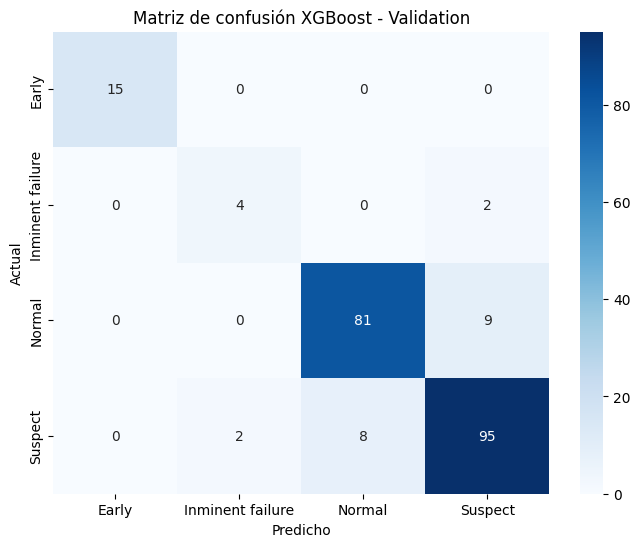

In [25]:

cm = confusion_matrix(y_valid, y_valid_pred)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.title("Matriz de confusión XGBoost - Validation")
plt.ylabel("Actual")
plt.xlabel("Predicho")
plt.savefig(f"{dir_artifacts}/matriz_confusion_xgboost_validacion.png", dpi=300, bbox_inches='tight')

if usar_wandb:
    wandb.log({"matriz_confusion_xgboost_validacion": wandb.Image(plt)})
    
plt.show()

## Evaluación - Test


In [26]:
best_model = grid.best_estimator_

y_test_pred = best_model.predict(X_test_2d)

In [27]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "test/precision": precision,
        "test/recall": recall,
        "test/f1_score": f1
    })

Accuracy: 0.9074074074074074
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       0.91      0.91      0.91        11
          Normal       0.91      0.88      0.90       180
         Suspect       0.90      0.91      0.91       211

        accuracy                           0.91       432
       macro avg       0.92      0.93      0.92       432
    weighted avg       0.91      0.91      0.91       432



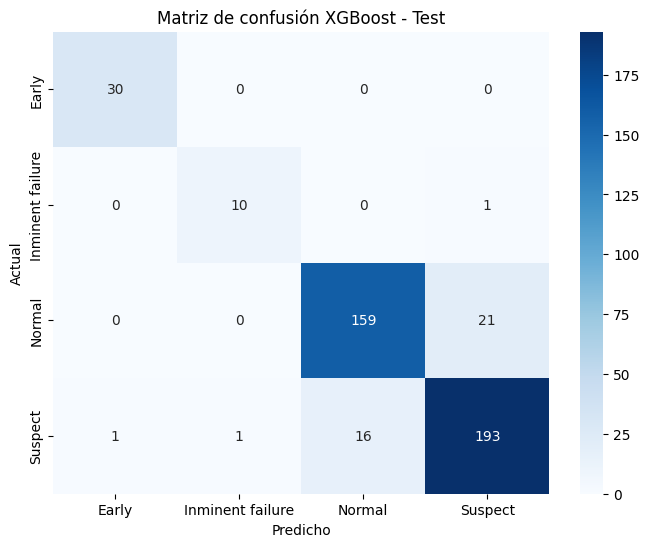

In [28]:

cm = confusion_matrix(y_test, y_test_pred)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.title("Matriz de confusión XGBoost - Test")
plt.ylabel("Actual")
plt.xlabel("Predicho")
plt.savefig(f"{dir_artifacts}/matriz_confusion_xgboost_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_xgboost_test": wandb.Image(plt)})
plt.show()

In [29]:
# Finalizar la ejecución
if usar_wandb:
    run.finish()

test/f1_score,▁▁
test/precision,▁▁
test/recall,▁▁
test/f1_score,0.90279
test/precision,0.90284
test/recall,0.90278


# MK - CNN


In [30]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Flatten, Dropout

def make_build_model(X, num_classes):
    def build_model(hp):
        model = Sequential([
            Conv1D(
                filters=hp.Int('filters_1', min_value=16, max_value=128, step=16),
                kernel_size=hp.Choice('kernel_size_1', values=[2, 3, 5]),
                activation="relu",
                padding='same',
                input_shape=(X.shape[1], X.shape[2])
            ),
            MaxPooling1D(pool_size=2),
            Conv1D(
                filters=hp.Int('filters_2', min_value=32, max_value=256, step=32),
                kernel_size=hp.Choice('kernel_size_2', values=[2, 3, 5]),
                activation="relu",
                padding='same'
            ),
            Flatten(),
            Dense(
                units=hp.Int('dense_units', min_value=32, max_value=256, step=32),
                activation="relu"
            ),
            Dropout(
                rate=hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)
            ),
            Dense(num_classes, activation="softmax")
        ])
        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
            ),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy', F1MacroScore(num_classes=num_classes)]
        )
        return model
    return build_model

# Uso — pasás X_train y num_classes acá
eval_metric = "val_f1_score" 
tuner = kt.Hyperband(
    make_build_model(X_train, len(np.unique(y_train))),  
    objective=kt.Objective(eval_metric, direction='max'),
    max_epochs=40,
    factor=3,
    directory='kt_results',
    project_name='cnn_vibraciones'
)

# Callback para detener early si no mejora
stop_early_monitor = 'val_loss'  
stop_early = tf.keras.callbacks.EarlyStopping(monitor=stop_early_monitor, patience=5)

# Búsqueda de hiperparámetros
tuner.search(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early]
)

# Ver resumen de los mejores resultados
tuner.results_summary()

# Obtener el mejor modelo
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Mejores hiperparámetros encontrados:
  filters_1:   {best_hps.get('filters_1')}
  filters_2:   {best_hps.get('filters_2')}
  kernel_1:    {best_hps.get('kernel_size_1')}
  kernel_2:    {best_hps.get('kernel_size_2')}
  dense_units: {best_hps.get('dense_units')}
  dropout:     {best_hps.get('dropout')}
  lr:          {best_hps.get('lr')}
""")

if usar_wandb:
    config_params = {f"param_{k}": v for k, v in best_hps.values.items()}
    config_params["param_metrica_evaluacion"] = eval_metric
    config_params["param_stop_early_monitor"] = stop_early_monitor


Reloading Tuner from kt_results/cnn_vibraciones/tuner0.json
Results summary
Results in kt_results/cnn_vibraciones
Showing 10 best trials
Objective(name="val_f1_score", direction="max")

Trial 0067 summary
Hyperparameters:
filters_1: 128
kernel_size_1: 3
filters_2: 64
kernel_size_2: 2
dense_units: 32
dropout: 0.4
lr: 0.0015980108835268547
tuner/epochs: 14
tuner/initial_epoch: 5
tuner/bracket: 2
tuner/round: 1
tuner/trial_id: 0056
Score: 0.9618614912033081

Trial 0084 summary
Hyperparameters:
filters_1: 128
kernel_size_1: 5
filters_2: 32
kernel_size_2: 3
dense_units: 64
dropout: 0.2
lr: 0.00025529484165240227
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0079
Score: 0.9582096338272095

Trial 0077 summary
Hyperparameters:
filters_1: 64
kernel_size_1: 3
filters_2: 192
kernel_size_2: 3
dense_units: 160
dropout: 0.5
lr: 0.001800627430497124
tuner/epochs: 14
tuner/initial_epoch: 0
tuner/bracket: 1
tuner/round: 0
Score: 0.9566235542297363

Trial 0048 

In [31]:
if usar_wandb:
    # Iniciar run de wandb
    timestap_str = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M")
    run = wandb.init(
        entity="maanmuri-marck",
        project="TF_CEIA_Clasificador_Vibraciones",
        name=f"CNN_Agregados_v5_{timestap_str}",
        tags=["cnn", "hyperparameter_tuning", "precision_macro"],
        config=config_params
    )

wandb: WARNING Artifact "run_90w1l4n4_model" already exists with the same content. No new version will be created.


In [32]:
# Entrenar el modelo final con los mejores hiperparámetros
callbacks_list = [stop_early]

if usar_wandb:
    callbacks_list.append(WandbMetricsLogger())
    callbacks_list.append(WandbModelCheckpoint(
    filepath=f"{dir_artifacts}/best_cnn_model.keras", 
    monitor=stop_early_monitor, 
    save_best_only=True,
    load_weights_on_restart=True
))

best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_data=(X_valid, y_valid),
    callbacks=callbacks_list
)

wandb: WARNING When using `save_best_only`, ensure that the `filepath` argument contains formatting placeholders like `{epoch:02d}` or `{batch:02d}`. This ensures correct interpretation of the logged artifacts.
2026-04-20 17:53:16.807933: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-20 17:53:16.974796: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-20 17:53:16.976383: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node re

Epoch 1/40


2026-04-20 17:53:18.360738: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8902
2026-04-20 17:53:18.853921: W external/local_xla/xla/service/gpu/llvm_gpu_backend/gpu_backend_lib.cc:504] Can't find libdevice directory ${CUDA_DIR}/nvvm/libdevice. This may result in compilation or runtime failures, if the program we try to run uses routines from libdevice.
Searched for CUDA in the following directories:
  ./cuda_sdk_lib
  /usr/local/cuda-12.2
  /usr/local/cuda
  /home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/tensorflow/python/platform/../../../nvidia/cuda_nvcc
  /home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/tensorflow/python/platform/../../../../nvidia/cuda_nvcc
  .
You can choose the search directory by setting xla_gpu_cuda_data_dir in HloModule's DebugOptions.  For most apps, setting the environment variable XLA_FLAGS=--xla_gpu_c

204/204 [==============================] - 6s 12ms/step - loss: 0.7006 - accuracy: 0.7046 - f1_score: 0.7221 - val_loss: 0.5131 - val_accuracy: 0.7824 - val_f1_score: 0.7711
Epoch 2/40
204/204 [==============================] - 1s 5ms/step - loss: 0.4929 - accuracy: 0.8111 - f1_score: 0.8251 - val_loss: 0.4091 - val_accuracy: 0.8333 - val_f1_score: 0.8178
Epoch 3/40
204/204 [==============================] - 1s 5ms/step - loss: 0.4222 - accuracy: 0.8215 - f1_score: 0.8454 - val_loss: 0.3940 - val_accuracy: 0.8519 - val_f1_score: 0.8397
Epoch 4/40
204/204 [==============================] - 1s 6ms/step - loss: 0.3877 - accuracy: 0.8437 - f1_score: 0.8682 - val_loss: 0.3901 - val_accuracy: 0.8333 - val_f1_score: 0.8295
Epoch 5/40
204/204 [==============================] - 1s 6ms/step - loss: 0.3753 - accuracy: 0.8523 - f1_score: 0.8683 - val_loss: 0.4324 - val_accuracy: 0.8333 - val_f1_score: 0.8209
Epoch 6/40
204/204 [==============================] - 1s 5ms/step - loss: 0.3512 - accurac

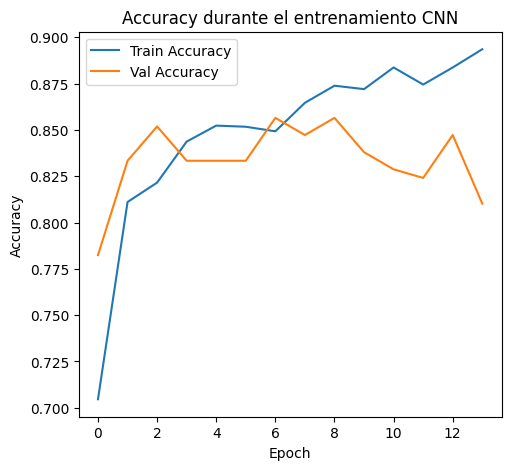

In [33]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento CNN')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.savefig(f"{dir_artifacts}/accuracy_epoch_cnn.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"accuracy_epoch_cnn_validacion": wandb.Image(plt)})
    
plt.legend()

In [34]:
# guardar el modelo entrenado 
best_model.save(f"{dir_artifacts}/best_cnn_model.h5", save_format='h5')

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluación - Validation

In [35]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_valid_pred = best_model.predict(X_valid)
y_valid_pred = np.argmax(y_valid_pred, axis=1)

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "validation/precision": precision,
        "validation/recall": recall,
        "validation/f1_score": f1
    })

7/7 [==============================] - 0s 29ms/step
Accuracy: 0.8101851851851852
                  precision    recall  f1-score   support

           Early       1.00      1.00      1.00        15
Inminent failure       0.71      0.83      0.77         6
          Normal       0.93      0.62      0.75        90
         Suspect       0.74      0.94      0.83       105

        accuracy                           0.81       216
       macro avg       0.85      0.85      0.84       216
    weighted avg       0.84      0.81      0.80       216



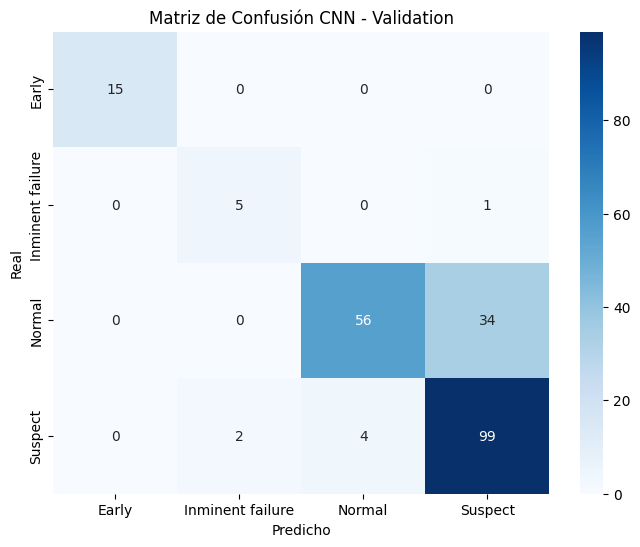

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión CNN - Validation")
plt.savefig(f"{dir_artifacts}/matriz_confusion_cnn_validation.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_cnn_validation": wandb.Image(plt)})
    
plt.show()

## Evaluacion - Test

In [37]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_test_pred = best_model.predict(X_test)
y_test_pred = np.argmax(y_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "test/precision": precision,
        "test/recall": recall,
        "test/f1_score": f1
    })

14/14 [==============================] - 0s 13ms/step
Accuracy: 0.8032407407407407
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       0.60      0.55      0.57        11
          Normal       0.93      0.63      0.75       180
         Suspect       0.74      0.93      0.82       211

        accuracy                           0.80       432
       macro avg       0.81      0.78      0.78       432
    weighted avg       0.83      0.80      0.80       432



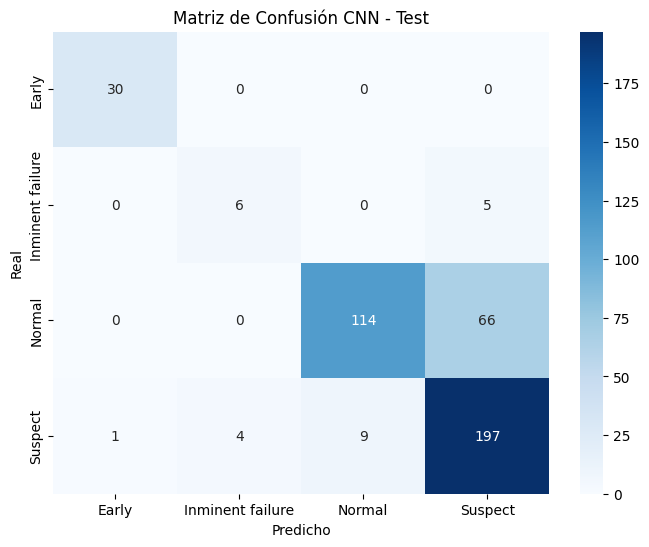

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión CNN - Test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_cnn_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_cnn_test": wandb.Image(plt)})
    
plt.show()

In [39]:
# Finalizar la ejecución
if usar_wandb:
    run.finish()

epoch/accuracy,▁▅▅▆▆▆▆▇▇▇█▇██
epoch/epoch,▁▂▂▃▃▄▄▅▅▆▆▇▇█
epoch/f1_score,▁▅▅▆▆▆▆▇▇▇█▇██
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▅▄▃▃▂▂▂▂▂▁▂▁▁
epoch/val_accuracy,▁▆█▆▆▆█▇█▆▅▅▇▄
epoch/val_f1_score,▁▄▅▅▄▇███▆▆▆█▅
epoch/val_loss,█▄▃▃▅▄▂▂▁▁▂▄▂▇
test/f1_score,▁
test/precision,▁
+4,...


# RNN


In [40]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

def make_build_model(X_train, num_classes):
    def build_model(hp):
        model = Sequential([

            SimpleRNN(
                units=hp.Int('rnn_units_1', min_value=32, max_value=256, step=32),
                return_sequences=True,
                input_shape=(X_train.shape[1], X_train.shape[2])
            ),

            Dropout(
                rate=hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)
            ),

            SimpleRNN(
                units=hp.Int('rnn_units_2', min_value=16, max_value=128, step=16)
            ),

            Dense(
                units=hp.Int('dense_units', min_value=32, max_value=256, step=32),
                activation="relu"
            ),

            Dense(num_classes, activation="softmax")
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
            ),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy",
                # tf.keras.metrics.Precision(name='precision'),
                # tf.keras.metrics.Recall(name='recall'),
                F1MacroScore(num_classes=num_classes)]
        )

        return model
    return build_model

eval_metric = "val_f1_score"  # nombre de la métrica personalizada que definimos
tuner = kt.Hyperband(
    make_build_model(X_train, num_classes),
    objective=kt.Objective(eval_metric, direction='max'),
    max_epochs=40,
    factor=3,
    directory='kt_results',
    project_name='rnn_vibraciones'
)

stop_early_monitor = 'val_loss'  # o 'val_f1_score' si querés monitorear la métrica personalizada
stop_early = tf.keras.callbacks.EarlyStopping(monitor=stop_early_monitor, patience=5)

tuner.search(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early]
)

tuner.results_summary()

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Mejores hiperparámetros encontrados:
  rnn_units_1: {best_hps.get('rnn_units_1')}
  rnn_units_2: {best_hps.get('rnn_units_2')}
  dropout:     {best_hps.get('dropout_1')}
  dense_units: {best_hps.get('dense_units')}
  lr:          {best_hps.get('lr')}
""")

if usar_wandb:
    config_params = {f"param_{k}": v for k, v in best_hps.values.items()}
    config_params["param_metrica_evaluacion"] = eval_metric
    config_params["param_stop_early_monitor"] = stop_early_monitor



Reloading Tuner from kt_results/rnn_vibraciones/tuner0.json
Results summary
Results in kt_results/rnn_vibraciones
Showing 10 best trials
Objective(name="val_f1_score", direction="max")

Trial 0061 summary
Hyperparameters:
rnn_units_1: 96
dropout_1: 0.4
rnn_units_2: 80
dense_units: 64
lr: 0.0007775212063831087
tuner/epochs: 14
tuner/initial_epoch: 5
tuner/bracket: 2
tuner/round: 1
tuner/trial_id: 0052
Score: 0.9650602340698242

Trial 0081 summary
Hyperparameters:
rnn_units_1: 128
dropout_1: 0.30000000000000004
rnn_units_2: 112
dense_units: 192
lr: 0.0004264401157975197
tuner/epochs: 40
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.9633245468139648

Trial 0078 summary
Hyperparameters:
rnn_units_1: 64
dropout_1: 0.5
rnn_units_2: 16
dense_units: 96
lr: 0.0004645769617789411
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0074
Score: 0.9623860716819763

Trial 0080 summary
Hyperparameters:
rnn_units_1: 96
dropout_1: 0.1
rnn_units_2: 

In [41]:
if usar_wandb:
    # Iniciar run de wandb
    timestap_str = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M")
    run = wandb.init(
        entity="maanmuri-marck",
        project="TF_CEIA_Clasificador_Vibraciones",
        name=f"RNN_Agregados_v5_{timestap_str}",
        tags=["rnn", "hyperparameter_tuning", "precision_macro"],
        config=config_params
    )

wandb: WARNING Artifact "run_35rxezm2_model" already exists with the same content. No new version will be created.


In [42]:

# Entrenar el modelo final con los mejores hiperparámetros
callbacks_list = [stop_early]

if usar_wandb:
    callbacks_list.append(WandbMetricsLogger())
    callbacks_list.append(WandbModelCheckpoint(
    filepath=f"{dir_artifacts}/best_rnn_model.keras", 
    monitor=stop_early_monitor, 
    save_best_only=True,
    load_weights_on_restart=True
))

best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    # validation_split=0.2,
    validation_data=(X_valid, y_valid),
    callbacks=callbacks_list
)

Epoch 1/40
204/204 [==============================] - 5s 16ms/step - loss: 0.6317 - accuracy: 0.7163 - f1_score: 0.7421 - val_loss: 0.4902 - val_accuracy: 0.7824 - val_f1_score: 0.7966
Epoch 2/40
204/204 [==============================] - 2s 11ms/step - loss: 0.4885 - accuracy: 0.7803 - f1_score: 0.8048 - val_loss: 0.4731 - val_accuracy: 0.7778 - val_f1_score: 0.7857
Epoch 3/40
204/204 [==============================] - 2s 11ms/step - loss: 0.4251 - accuracy: 0.8154 - f1_score: 0.8399 - val_loss: 0.3974 - val_accuracy: 0.8102 - val_f1_score: 0.8281
Epoch 4/40
204/204 [==============================] - 2s 11ms/step - loss: 0.3918 - accuracy: 0.8265 - f1_score: 0.8562 - val_loss: 0.4072 - val_accuracy: 0.8241 - val_f1_score: 0.8338
Epoch 5/40
204/204 [==============================] - 2s 12ms/step - loss: 0.3785 - accuracy: 0.8369 - f1_score: 0.8661 - val_loss: 0.3367 - val_accuracy: 0.8426 - val_f1_score: 0.8737
Epoch 6/40
204/204 [==============================] - 2s 11ms/step - loss: 

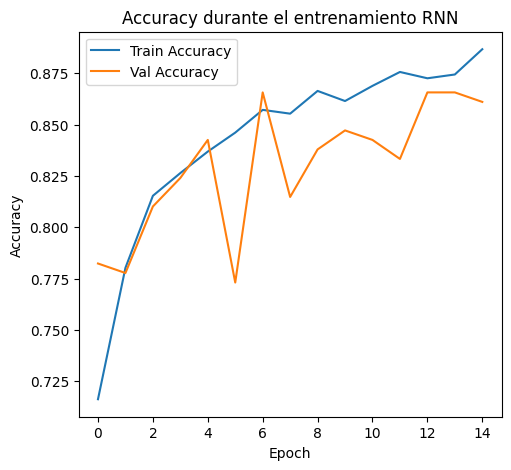

In [43]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento RNN')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.savefig(f"{dir_artifacts}/accuracy_epoch_rnn.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"accuracy_epoch_rnn_validacion": wandb.Image(plt)})
    
plt.legend()

In [44]:
# guardar el modelo entrenado 
best_model.save(f"{dir_artifacts}/best_rnn_model.h5", save_format='h5')

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluación - Validation

In [45]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_valid_pred = best_model.predict(X_valid)
y_valid_pred = np.argmax(y_valid_pred, axis=1)

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "validation/precision": precision,
        "validation/recall": recall,
        "validation/f1_score": f1
    })

7/7 [==============================] - 0s 3ms/step
Accuracy: 0.8611111111111112
                  precision    recall  f1-score   support

           Early       1.00      1.00      1.00        15
Inminent failure       0.71      0.83      0.77         6
          Normal       0.86      0.83      0.85        90
         Suspect       0.85      0.87      0.86       105

        accuracy                           0.86       216
       macro avg       0.86      0.88      0.87       216
    weighted avg       0.86      0.86      0.86       216



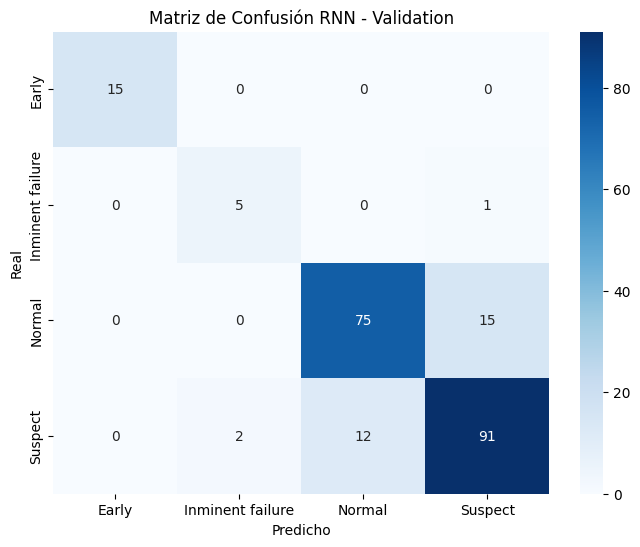

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión RNN - Validation")
plt.savefig(f"{dir_artifacts}/matriz_confusion_rnn_validation.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_rnn_validation": wandb.Image(plt)})

plt.show()

## Evaluación - Test

In [47]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_test_pred = best_model.predict(X_test)
y_test_pred = np.argmax(y_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "test/precision": precision,
        "test/recall": recall,
        "test/f1_score": f1
    })

14/14 [==============================] - 0s 3ms/step
Accuracy: 0.8564814814814815
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       0.64      0.64      0.64        11
          Normal       0.85      0.86      0.85       180
         Suspect       0.86      0.84      0.85       211

        accuracy                           0.86       432
       macro avg       0.83      0.84      0.83       432
    weighted avg       0.86      0.86      0.86       432



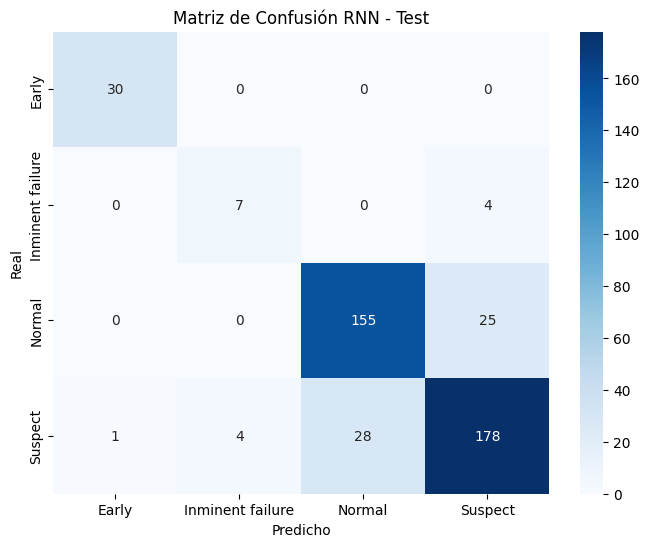

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión RNN - Test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_rnn_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_rnn_test": wandb.Image(plt)})

plt.show()

In [49]:
# Finalizar la ejecución
if usar_wandb:
    run.finish()

epoch/accuracy,▁▄▅▆▆▆▇▇▇▇▇█▇▇█
epoch/epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch/f1_score,▁▃▅▆▆▆▇▇▇▇▇█▇▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▅▄▃▃▃▃▂▂▂▂▂▂▂▁
epoch/val_accuracy,▂▁▄▅▆▁█▄▆▇▆▆███
epoch/val_f1_score,▂▂▄▅▇▁█▆▄▆▅▃▆▆▇
epoch/val_loss,▇▆▃▄▁█▂▅▃▁▃▃▂▃▂
test/f1_score,▁
test/precision,▁
+4,...


# LSTM

In [50]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def make_build_model(X_train, num_classes):
    def build_model(hp):
        model = Sequential([

            LSTM(
                units=hp.Int('lstm_units_1', min_value=32, max_value=256, step=32),
                return_sequences=True,
                input_shape=(X_train.shape[1], X_train.shape[2])
            ),

            Dropout(
                rate=hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)
            ),

            LSTM(
                units=hp.Int('lstm_units_2', min_value=16, max_value=128, step=16)
            ),

            Dense(
                units=hp.Int('dense_units', min_value=32, max_value=256, step=32),
                activation="relu"
            ),

            Dense(num_classes, activation="softmax")
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
            ),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy",
                # tf.keras.metrics.Precision(name='precision'),
                # tf.keras.metrics.Recall(name='recall'),
                F1MacroScore(num_classes=num_classes)]
        )

        return model
    return build_model

eval_metric = "val_f1_score"  
tuner = kt.Hyperband(
    make_build_model(X_train, num_classes),
    objective=kt.Objective(eval_metric, direction='max'),
    max_epochs=40,
    factor=3,
    directory='kt_results',
    project_name='lstm_vibraciones'
)

stop_early_monitor = 'val_loss'  
stop_early = tf.keras.callbacks.EarlyStopping(monitor=stop_early_monitor, patience=5)

# Búsqueda de hiperparámetros
tuner.search(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early]
)

tuner.results_summary()

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Mejores hiperparámetros encontrados:
  lstm_units_1: {best_hps.get('lstm_units_1')}
  lstm_units_2: {best_hps.get('lstm_units_2')}
  dropout:      {best_hps.get('dropout_1')}
  dense_units:  {best_hps.get('dense_units')}
  lr:           {best_hps.get('lr')}
""")

if usar_wandb:
    config_params = {f"param_{k}": v for k, v in best_hps.values.items()}
    config_params["param_metrica_evaluacion"] = eval_metric
    config_params["param_stop_early_monitor"] = stop_early_monitor


Reloading Tuner from kt_results/lstm_vibraciones/tuner0.json
Results summary
Results in kt_results/lstm_vibraciones
Showing 10 best trials
Objective(name="val_f1_score", direction="max")

Trial 0086 summary
Hyperparameters:
lstm_units_1: 32
dropout_1: 0.4
lstm_units_2: 80
dense_units: 128
lr: 0.008326380697068002
tuner/epochs: 40
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.957563042640686

Trial 0083 summary
Hyperparameters:
lstm_units_1: 128
dropout_1: 0.1
lstm_units_2: 128
dense_units: 224
lr: 0.0005167397035568562
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0074
Score: 0.9575486779212952

Trial 0084 summary
Hyperparameters:
lstm_units_1: 224
dropout_1: 0.5
lstm_units_2: 16
dense_units: 160
lr: 0.003687492934224323
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0076
Score: 0.9575390219688416

Trial 0082 summary
Hyperparameters:
lstm_units_1: 128
dropout_1: 0.1
lstm_units_2: 128


In [51]:
if usar_wandb:
    # Iniciar run de wandb
    timestap_str = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M")
    run = wandb.init(
        entity="maanmuri-marck",
        project="TF_CEIA_Clasificador_Vibraciones",
        name=f"LSTM_Agregados_v5_{timestap_str}",
        tags=["lstm", "hyperparameter_tuning", "precision_macro"],
        config=config_params
    )

wandb: WARNING Artifact "run_or8j2yul_model" already exists with the same content. No new version will be created.


In [52]:
# Entrenar el modelo final con los mejores hiperparámetros
callbacks_list = [stop_early]

if usar_wandb:
    callbacks_list.append(WandbMetricsLogger())
    callbacks_list.append(WandbModelCheckpoint(
    filepath=f"{dir_artifacts}/best_lstm_model.keras", 
    monitor=stop_early_monitor, 
    save_best_only=True,
    load_weights_on_restart=True
))

best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    # validation_split=0.2,
    validation_data=(X_valid, y_valid),
    callbacks=callbacks_list
)

Epoch 1/40
204/204 [==============================] - 5s 12ms/step - loss: 0.6140 - accuracy: 0.7052 - f1_score: 0.7259 - val_loss: 0.4954 - val_accuracy: 0.7361 - val_f1_score: 0.7273
Epoch 2/40
204/204 [==============================] - 1s 7ms/step - loss: 0.4639 - accuracy: 0.7975 - f1_score: 0.8165 - val_loss: 0.4031 - val_accuracy: 0.8380 - val_f1_score: 0.8460
Epoch 3/40
204/204 [==============================] - 1s 7ms/step - loss: 0.4127 - accuracy: 0.8308 - f1_score: 0.8597 - val_loss: 0.3880 - val_accuracy: 0.8426 - val_f1_score: 0.8340
Epoch 4/40
204/204 [==============================] - 1s 7ms/step - loss: 0.3780 - accuracy: 0.8308 - f1_score: 0.8566 - val_loss: 0.4096 - val_accuracy: 0.8194 - val_f1_score: 0.8576
Epoch 5/40
204/204 [==============================] - 1s 7ms/step - loss: 0.3384 - accuracy: 0.8597 - f1_score: 0.8851 - val_loss: 0.3938 - val_accuracy: 0.8565 - val_f1_score: 0.8659
Epoch 6/40
204/204 [==============================] - 1s 7ms/step - loss: 0.330

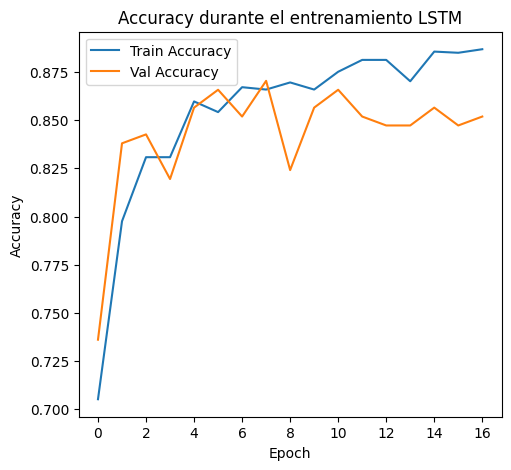

In [53]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento LSTM')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.savefig(f"{dir_artifacts}/accuracy_epoch_lstm.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"accuracy_epoch_lstm_validacion": wandb.Image(plt)})
    
plt.legend()

In [54]:
# guardar el modelo entrenado 
best_model.save(f"{dir_artifacts}/best_lstm_model.h5", save_format='h5')

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluación - Validation

In [55]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_valid_pred = best_model.predict(X_valid)
y_valid_pred = np.argmax(y_valid_pred, axis=1)

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "validation/precision": precision,
        "validation/recall": recall,
        "validation/f1_score": f1
    })

7/7 [==============================] - 1s 3ms/step
Accuracy: 0.8518518518518519
                  precision    recall  f1-score   support

           Early       1.00      1.00      1.00        15
Inminent failure       0.62      0.83      0.71         6
          Normal       0.84      0.86      0.85        90
         Suspect       0.86      0.83      0.84       105

        accuracy                           0.85       216
       macro avg       0.83      0.88      0.85       216
    weighted avg       0.85      0.85      0.85       216



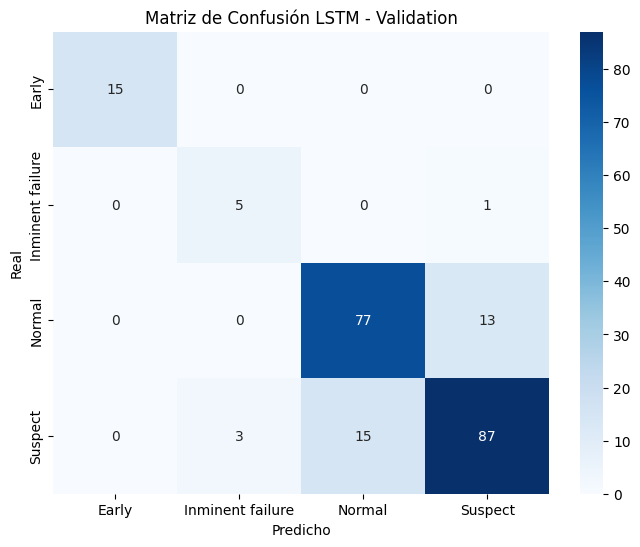

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión LSTM - Validation")
plt.savefig(f"{dir_artifacts}/matriz_confusion_lstm_validation.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_lstm_validation": wandb.Image(plt)})
    
plt.show()

## Evaluación - Test

In [57]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_test_pred = best_model.predict(X_test)
y_test_pred = np.argmax(y_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "test/precision": precision,
        "test/recall": recall,
        "test/f1_score": f1
    })

14/14 [==============================] - 0s 2ms/step
Accuracy: 0.8495370370370371
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       0.47      0.73      0.57        11
          Normal       0.83      0.90      0.86       180
         Suspect       0.89      0.79      0.84       211

        accuracy                           0.85       432
       macro avg       0.79      0.85      0.81       432
    weighted avg       0.86      0.85      0.85       432



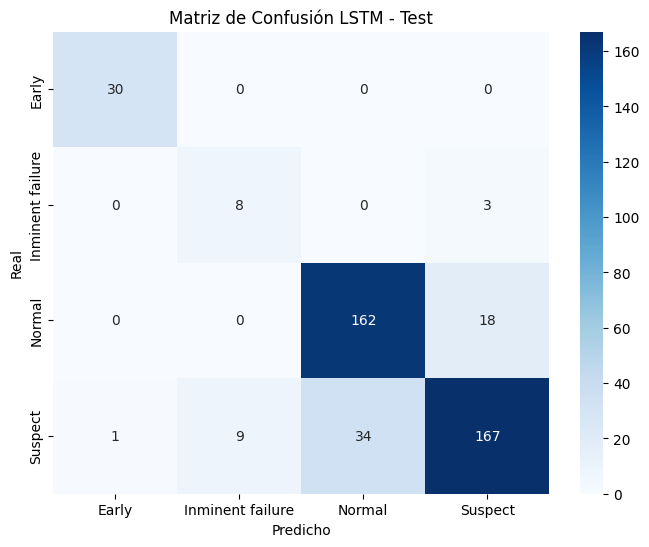

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión LSTM - Test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_lstm_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_lstm_test": wandb.Image(plt)})
    
plt.show()

In [59]:
# Finalizar la ejecución
if usar_wandb:
    run.finish()

epoch/accuracy,▁▅▆▆▇▇▇▇▇▇███▇███
epoch/epoch,▁▁▂▂▃▃▄▄▅▅▅▆▆▇▇██
epoch/f1_score,▁▄▆▆▇▇▇▇▇▇███▇███
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▅▄▃▃▂▂▂▂▂▂▂▁▂▁▁▁
epoch/val_accuracy,▁▆▇▅▇█▇█▆▇█▇▇▇▇▇▇
epoch/val_f1_score,▁▆▅▆▇▆▆█▇▆▆█▆▇▆▇▆
epoch/val_loss,█▄▃▄▃▃▃▂▂▁▂▁▅▄▅▂▃
test/f1_score,▁
test/precision,▁
+4,...


# Deep Neural Network

In [60]:
# Dado que este modelo espera una entrada 2D, necesitamos aplanar cada muestra de 8xfeatures a un vector de features. Esto se hace con reshape, manteniendo el número de muestras (X_train.shape[0]) y aplanando el resto (-1).
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d  = X_test.reshape(X_test.shape[0], -1)
X_valid_2d   = X_valid.reshape(X_valid.shape[0], -1)

print(X_train_2d.shape)  # (1724, 168)
print(X_test_2d.shape)   # (431, 168)
print(X_valid_2d.shape) # (216, 168)

(1625, 24)
(432, 24)
(216, 24)


In [61]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def make_build_model(X_train, num_classes):
    num_features = X_train.shape[1] * X_train.shape[2]

    def build_model(hp):
        model = Sequential([

            Dense(
                units=hp.Int('dense_units_1', min_value=64, max_value=256, step=32),
                activation="relu",
                input_shape=(num_features,)
            ),

            Dense(
                units=hp.Int('dense_units_2', min_value=32, max_value=128, step=32),
                activation="relu"
            ),

            Dense(
                units=hp.Int('dense_units_3', min_value=16, max_value=64, step=16),
                activation="relu"
            ),

            Dropout(
                rate=hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)
            ),

            Dense(num_classes, activation="softmax")
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
            ),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy",
                # tf.keras.metrics.Precision(name='precision'),
                # tf.keras.metrics.Recall(name='recall'),
                F1MacroScore(num_classes=num_classes)]
        )

        return model
    return build_model


eval_metric = "val_f1_score" 
tuner = kt.Hyperband(
    make_build_model(X_train, num_classes),
    objective=kt.Objective(eval_metric, direction='max'),
    max_epochs=40,
    factor=3,
    directory='kt_results',
    project_name='mlp_vibraciones'
)

stop_early_monitor = 'val_loss'  
stop_early = tf.keras.callbacks.EarlyStopping(monitor=stop_early_monitor, patience=5)

# aplanar X a 2D antes de entrenar
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_val_2d   = X_valid.reshape(X_valid.shape[0], -1)

tuner.search(
    X_train_2d,
    y_train,
    epochs=40,
    batch_size=8,
    validation_data=(X_val_2d, y_valid),
    callbacks=[stop_early]
)

tuner.results_summary()

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Mejores hiperparámetros encontrados:
  dense_units_1: {best_hps.get('dense_units_1')}
  dense_units_2: {best_hps.get('dense_units_2')}
  dense_units_3: {best_hps.get('dense_units_3')}
  dropout:       {best_hps.get('dropout')}
  lr:            {best_hps.get('lr')}
""")

if usar_wandb:
    config_params = {f"param_{k}": v for k, v in best_hps.values.items()}
    config_params["param_metrica_evaluacion"] = eval_metric
    config_params["param_stop_early_monitor"] = stop_early_monitor

Reloading Tuner from kt_results/mlp_vibraciones/tuner0.json
Results summary
Results in kt_results/mlp_vibraciones
Showing 10 best trials
Objective(name="val_f1_score", direction="max")

Trial 0077 summary
Hyperparameters:
dense_units_1: 96
dense_units_2: 64
dense_units_3: 32
dropout: 0.5
lr: 0.0014825733072079664
tuner/epochs: 14
tuner/initial_epoch: 0
tuner/bracket: 1
tuner/round: 0
Score: 0.979971170425415

Trial 0087 summary
Hyperparameters:
dense_units_1: 128
dense_units_2: 64
dense_units_3: 64
dropout: 0.5
lr: 0.0038539501398167143
tuner/epochs: 40
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.979971170425415

Trial 0078 summary
Hyperparameters:
dense_units_1: 192
dense_units_2: 32
dense_units_3: 32
dropout: 0.1
lr: 0.0002401891792157938
tuner/epochs: 14
tuner/initial_epoch: 0
tuner/bracket: 1
tuner/round: 0
Score: 0.9786841869354248

Trial 0050 summary
Hyperparameters:
dense_units_1: 64
dense_units_2: 32
dense_units_3: 64
dropout: 0.30000000000000004
lr: 0.00199

In [62]:
if usar_wandb:
    # Iniciar run de wandb
    timestap_str = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M")
    run = wandb.init(
        entity="maanmuri-marck",
        project="TF_CEIA_Clasificador_Vibraciones",
        name=f"DNN_Agregados_v5_{timestap_str}",
        tags=["dnn", "hyperparameter_tuning", "precision_macro"],
        config=config_params
    )

In [63]:
# Entrenar el modelo final con los mejores hiperparámetros
callbacks_list = [stop_early]

if usar_wandb:
    callbacks_list.append(WandbMetricsLogger())
    callbacks_list.append(WandbModelCheckpoint(
    filepath=f"{dir_artifacts}/best_dnn_model.keras", 
    monitor=stop_early_monitor, 
    save_best_only=True,
    load_weights_on_restart=True
))

best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train_2d,
    y_train,
    epochs=40,
    batch_size=8,
    validation_data=(X_val_2d, y_valid),
    callbacks=callbacks_list
)

Epoch 1/40
204/204 [==============================] - 3s 9ms/step - loss: 0.8165 - accuracy: 0.6542 - f1_score: 0.6235 - val_loss: 0.5229 - val_accuracy: 0.8009 - val_f1_score: 0.8257
Epoch 2/40
204/204 [==============================] - 1s 5ms/step - loss: 0.5761 - accuracy: 0.7686 - f1_score: 0.7875 - val_loss: 0.4543 - val_accuracy: 0.8194 - val_f1_score: 0.8218
Epoch 3/40
204/204 [==============================] - 1s 5ms/step - loss: 0.4564 - accuracy: 0.8172 - f1_score: 0.8442 - val_loss: 0.4344 - val_accuracy: 0.7778 - val_f1_score: 0.7987
Epoch 4/40
204/204 [==============================] - 1s 5ms/step - loss: 0.3921 - accuracy: 0.8468 - f1_score: 0.8673 - val_loss: 0.4373 - val_accuracy: 0.7963 - val_f1_score: 0.8198
Epoch 5/40
204/204 [==============================] - 1s 5ms/step - loss: 0.3843 - accuracy: 0.8455 - f1_score: 0.8756 - val_loss: 0.4153 - val_accuracy: 0.8056 - val_f1_score: 0.8136
Epoch 6/40
204/204 [==============================] - 1s 5ms/step - loss: 0.3823

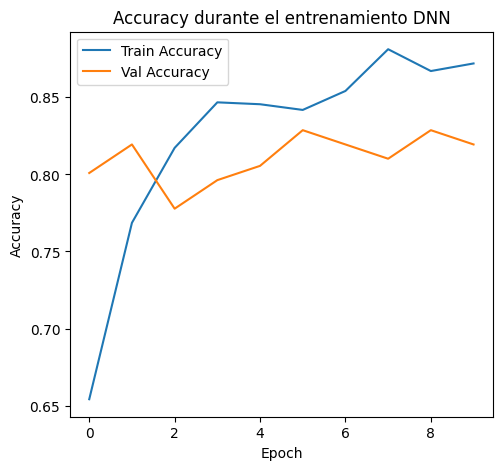

In [64]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento DNN')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.savefig(f"{dir_artifacts}/accuracy_epoch_dnn.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"accuracy_epoch_dnn_validacion": wandb.Image(plt)})
    
plt.legend()

In [65]:
# guardar el modelo entrenado 
best_model.save(f"{dir_artifacts}/best_dnn_model.h5")

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluación - Validation

In [66]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

y_valid_pred = best_model.predict(X_valid_2d)
y_valid_pred = np.argmax(y_valid_pred, axis=1)

print("Accuracy:", accuracy_score(y_valid, y_valid_pred))

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "validation/precision": precision,
        "validation/recall": recall,
        "validation/f1_score": f1
    })

7/7 [==============================] - 0s 2ms/step
Accuracy: 0.8194444444444444
                  precision    recall  f1-score   support

           Early       1.00      1.00      1.00        15
Inminent failure       0.56      0.83      0.67         6
          Normal       0.78      0.87      0.82        90
         Suspect       0.86      0.75      0.80       105

        accuracy                           0.82       216
       macro avg       0.80      0.86      0.82       216
    weighted avg       0.83      0.82      0.82       216



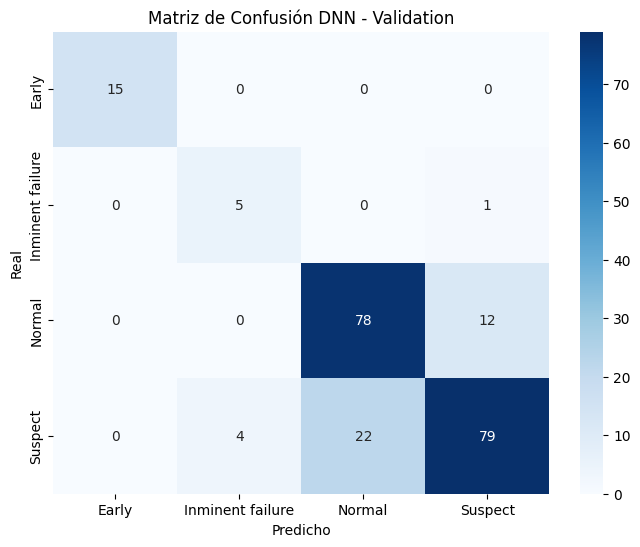

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_valid_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión DNN - Validation")
plt.savefig(f"{dir_artifacts}/matriz_confusion_dnn_validation.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_dnn_validation": wandb.Image(plt)})
    
plt.show()

## Evaluación - Test

In [68]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

y_test_pred = best_model.predict(X_test_2d)
y_test_pred = np.argmax(y_test_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    target_names=le.classes_
))

# loggear métricas de precisión, recall y F1-score en wandb
if usar_wandb:
    precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='weighted')

    wandb.log({
        "test/precision": precision,
        "test/recall": recall,
        "test/f1_score": f1
    })

14/14 [==============================] - 0s 2ms/step
Accuracy: 0.8518518518518519
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       0.64      0.64      0.64        11
          Normal       0.81      0.90      0.85       180
         Suspect       0.89      0.80      0.84       211

        accuracy                           0.85       432
       macro avg       0.83      0.83      0.83       432
    weighted avg       0.86      0.85      0.85       432



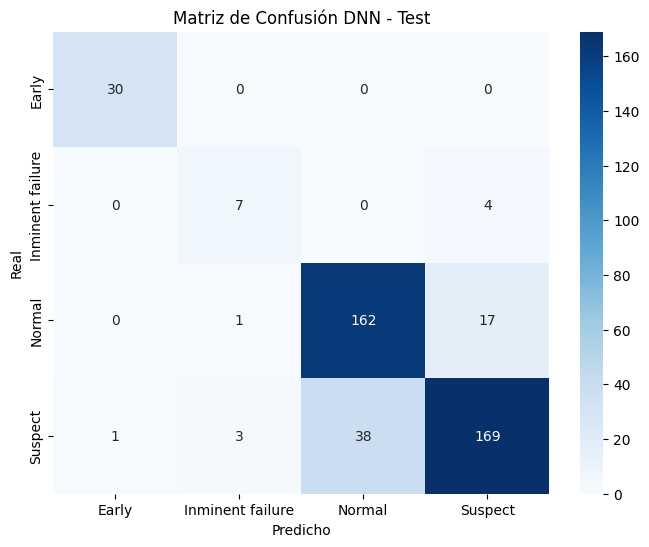

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión DNN - Test")
plt.savefig(f"{dir_artifacts}/matriz_confusion_dnn_test.png", dpi=300, bbox_inches='tight')
if usar_wandb:
    wandb.log({"matriz_confusion_dnn_test": wandb.Image(plt)})
    
plt.show()

In [70]:
# Finalizar la ejecución
if usar_wandb:
    run.finish()

epoch/accuracy,▁▅▆▇▇▇▇███
epoch/epoch,▁▂▃▃▄▅▆▆▇█
epoch/f1_score,▁▅▆▇▇▇▇███
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▅▃▂▂▂▂▁▁▁
epoch/val_accuracy,▄▇▁▄▅█▇▅█▇
epoch/val_f1_score,▅▄▁▄▃█▄▂█▄
epoch/val_loss,█▄▂▂▁▃▂▃▃▂
test/f1_score,▁
test/precision,▁
+4,...
